In [1]:
pip install torch torchvision matplotlib numpy

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [3]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 45.7MB/s]


In [4]:
latent_dim = 100
image_size = 64
channels = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
generator = Generator().to(device)

# Optional: Load trained model
# generator.load_state_dict(torch.load("generator.pth"))

generator.eval()  # Freeze weights

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

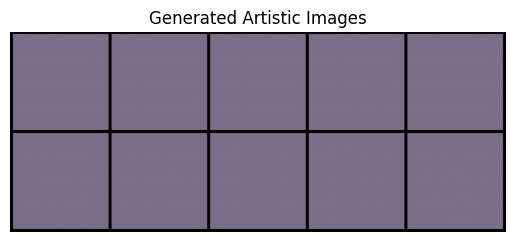

In [8]:
def generate_images(num_images=10):
    noise = torch.randn(num_images, latent_dim, 1, 1).to(device)
    fake_images = generator(noise).detach().cpu()

    fake_images = (fake_images + 1) / 2  # Denormalize

    grid = torchvision.utils.make_grid(fake_images, nrow=5)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title("Generated Artistic Images")
    plt.axis("off")
    plt.show()

generate_images(10)

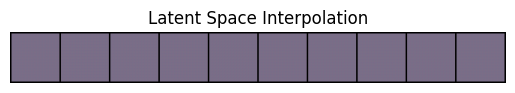

In [9]:
def interpolate():
    z1 = torch.randn(1, latent_dim, 1, 1).to(device)
    z2 = torch.randn(1, latent_dim, 1, 1).to(device)

    interpolations = []
    for alpha in np.linspace(0, 1, 10):
        z = (1 - alpha) * z1 + alpha * z2
        img = generator(z).detach().cpu()
        interpolations.append(img)

    interpolations = torch.cat(interpolations)
    interpolations = (interpolations + 1) / 2

    grid = torchvision.utils.make_grid(interpolations, nrow=10)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title("Latent Space Interpolation")
    plt.axis("off")
    plt.show()

interpolate()